# `dtd-link` — He, Guo & Liu's (2010) link-based day-to-day dynamics

**What.** The state is the aggregate LINK-flow vector, which moves each day toward the frozen-cost proximal target x*(v) = Proj_Ω(v − a t(v)) — a rational-behaviour adjustment that stays inside the OD-feasible polytope Ω. Its fixed point is Wardrop UE.

**Why it is in the benchmark.** Its distinctive signature is INVARIANCE: the emitted link flows never leave Ω (node balance ≈ 0 on every day), the He-Guo-Liu invariance principle — a different paradigm from route-swap (dtd-swap) that reaches the identical certified UE. See the
[model compendium](../../docs/MODELS.md) and the certificate design in
[docs/ARCHITECTURE.md](../../docs/ARCHITECTURE.md) (P1).

**Scope.** Runs the process on a built-in scenario and certifies the result; it does
not benchmark day-to-day models against each other. Reference: He, Guo & Liu (2010), *Transportation Research Part B* 44(4).

**Canon.** `[he2010linkbased]`, [docs/REFERENCES.md](../../docs/REFERENCES.md) / [docs/references.bib](../../docs/references.bib).

## How this notebook is graded

**A notebook never claims a number it does not compute in that cell.** Every scored
quantity below is recomputed live by the P1 `Evaluator` from the flows the model
emitted, in the cell where it is claimed. Model self-reports (the per-day gap/residual,
the Lyapunov value) are shown only as provenance and diffed against the certificate,
exactly as the harness treats them ([README](../../README.md), *Certified, not
self-reported*).

In [1]:
# Setup. `dtd-link` is a core day-to-day model: a plain `pip install -e .` suffices —
# no optional extra, so no guard cell. The inline backend is Agg-based (headless CI
# renders into the notebook); NEVER matplotlib.use("Agg") in-kernel — it silently
# suppresses inline figure capture.
%matplotlib inline
import numpy as np

from tabench import (
    Budget,
    Evaluator,
    LinkBasedDTDModel,
    RngBundle,
    Trace,
    braess_scenario,
    viz,
)

## The scenario

The built-in Braess network (4 nodes, 5 links, one OD pair 1→2, demand 6). Scenarios are
frozen and content-hashed (P2) — the hash below is the benchmark instance's identity.

In [2]:
scenario = braess_scenario()
net = scenario.network
print(f"scenario      : {scenario.name}")
print(f"content hash  : {scenario.content_hash()[:16]}…")
print(f"links         : {net.n_links}  (tail→head: "
      + ", ".join(f"{i}->{j}" for i, j in zip(net.init_node, net.term_node)) + ")")
print(f"total demand  : {scenario.demand.total}")
print("task          : Wardrop UE fixed point")

scenario      : braess
content hash  : cf00f411cdccec88…
links         : 5  (tail→head: 1->3, 1->4, 3->4, 3->2, 4->2)
total demand  : 6.0
task          : Wardrop UE fixed point


## Run the adjustment process

The model contract ([CONTRIBUTING.md](../../CONTRIBUTING.md)): a model receives
`(scenario, budget, rng, trace)` and records one checkpoint per day — here a *budget
iteration is a day*. Everything the model writes into `self_report` (the per-day
gap/residual, the Lyapunov value) is provenance, not a score.

In [3]:
bundle_trace = Trace()
model = LinkBasedDTDModel()
model.solve(scenario, Budget(iterations=800, target_relative_gap=1e-8),
            RngBundle(0), bundle_trace)
final = bundle_trace.final
print(f"model            : {model.name}")
print(f"days simulated   : {final.coords.iterations}  "
      f"({final.coords.sp_calls} shortest-path calls)")
print(f"emitted flows    : {np.round(final.link_flows, 6)}")
print(f"self-reported gap     : {final.self_report['relative_gap']:.3e}  (provenance only)")

model            : dtd-link
days simulated   : 43  (44 shortest-path calls)
emitted flows    : [4. 2. 2. 2. 4.]
self-reported gap     : 7.403e-09  (provenance only)


## Certify (P1) — the fixed point AND the descent

The harness, never the model, computes every scored metric. Certified here: (1) the
terminal flows are the Wardrop UE — relative gap → 0 with the analytic Braess anchor
recomputed in-cell; (2) the day-to-day signature — Beckmann descends monotonically to
386 — plus this model's distinctive provenance measure.

In [4]:
evaluator = Evaluator(scenario)
metrics = evaluator.evaluate(final.link_flows)
gap = metrics["relative_gap"]
print(f"certified relative gap : {gap:.3e}")
print(f"feasible               : {metrics['feasible']:.0f}")
assert metrics["feasible"] == 1.0
assert gap < 1e-6
# Analytic Braess UE anchor, recomputed in-cell (flows (4,2,2,2,4), every route costs 92).
ref_flows = np.array([4.0, 2.0, 2.0, 2.0, 4.0])
assert evaluator.evaluate(ref_flows)["relative_gap"] < 1e-6
assert np.allclose(final.link_flows, ref_flows, atol=1e-4)
route_time = metrics["tstt"] / scenario.demand.total
print(f"route time (TSTT/D)    : {route_time:.4f}  (analytic UE: 92)")
assert abs(route_time - 92.0) < 1e-2
# Beckmann is a Lyapunov function: monotone non-increasing to the UE value 386.
beckmann = [s.self_report["beckmann"] for s in bundle_trace]
assert all(beckmann[i] >= beckmann[i + 1] - 1e-9 for i in range(len(beckmann) - 1))
assert abs(beckmann[-1] - 386.0) < 1e-2
print(f"Beckmann descent       : {beckmann[0]:.2f} → {beckmann[-1]:.2f}  (monotone ✓)")
# Honesty diff (P1): the terminal self-reported Beckmann value against the SAME
# quantity the certificate itself computes from final.link_flows -- the Lyapunov
# claim is not backed by self-report alone.
assert np.isclose(beckmann[-1], metrics["beckmann_objective"], atol=1e-6)
# INVARIANCE (He, Guo & Liu 2010): the LINK-flow state never leaves the OD-feasible set
# Ω — node balance is at the noise floor on EVERY recorded day, not only at convergence.
worst_balance = max(
    evaluator.evaluate(s.link_flows)["node_balance_residual"] for s in bundle_trace
)
print(f"worst node-balance/day : {worst_balance:.2e}  (stays inside Ω every day)")
assert worst_balance <= 1e-6 * scenario.demand.total

certified relative gap : 7.403e-09
feasible               : 1
route time (TSTT/D)    : 92.0000  (analytic UE: 92)
Beckmann descent       : 438.00 → 386.00  (monotone ✓)
worst node-balance/day : 3.55e-15  (stays inside Ω every day)


## Visualize

Both figures come from `tabench.viz`, the house visualizer — every plotted number is one
certified above. Left/top: the certified terminal link flows on the network. Right/bottom:
the emitted flows against the fixed point recomputed in the certify cell — points on the
`y = x` guide mean the day-to-day process settled on it link-for-link.

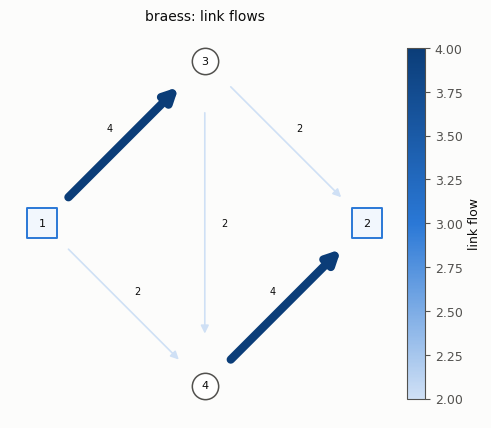

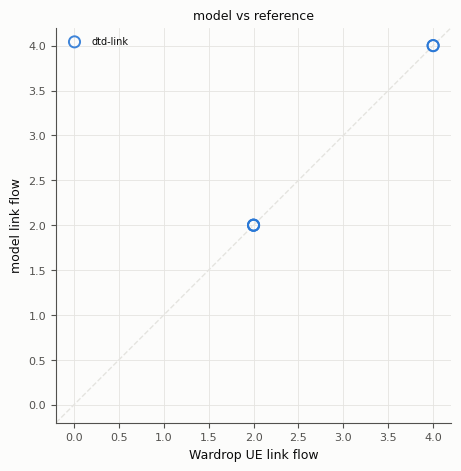

In [5]:
# Certified terminal flows on the network (house style via tabench.viz).
display(viz.plot_network_flows(net, final.link_flows))

# Emitted flows vs the Wardrop UE recomputed above (off-diagonal == not settled).
display(viz.plot_flow_scatter(("Wardrop UE", ref_flows), {"dtd-link": final.link_flows}))

## Takeaways & pointers

- **Certified, not self-reported.** The gap came from `Evaluator`; the per-day node-balance invariance was certified from the emitted flows, not the self-report.
- **The day-to-day signature is the point.** A UE/SUE *solver* gives you the fixed
  point; a day-to-day *model* gives you the adjustment path to it.
- **Where next.** the route-swap paradigm [`dtd-swap`](01-dtd-swap.ipynb); the route-space projected gradient [`dtd-friesz`](04-dtd-friesz.ipynb); the lineage in the
  [model compendium](../../docs/MODELS.md).